ID#                  0.0
Balance              0.0
Qual_miles           0.0
cc1_miles            0.0
cc2_miles            0.0
cc3_miles            0.0
Bonus_miles          0.0
Bonus_trans          0.0
Flight_miles_12mo    0.0
Flight_trans_12      0.0
Days_since_enroll    0.0
Award?               0.0
dtype: float64


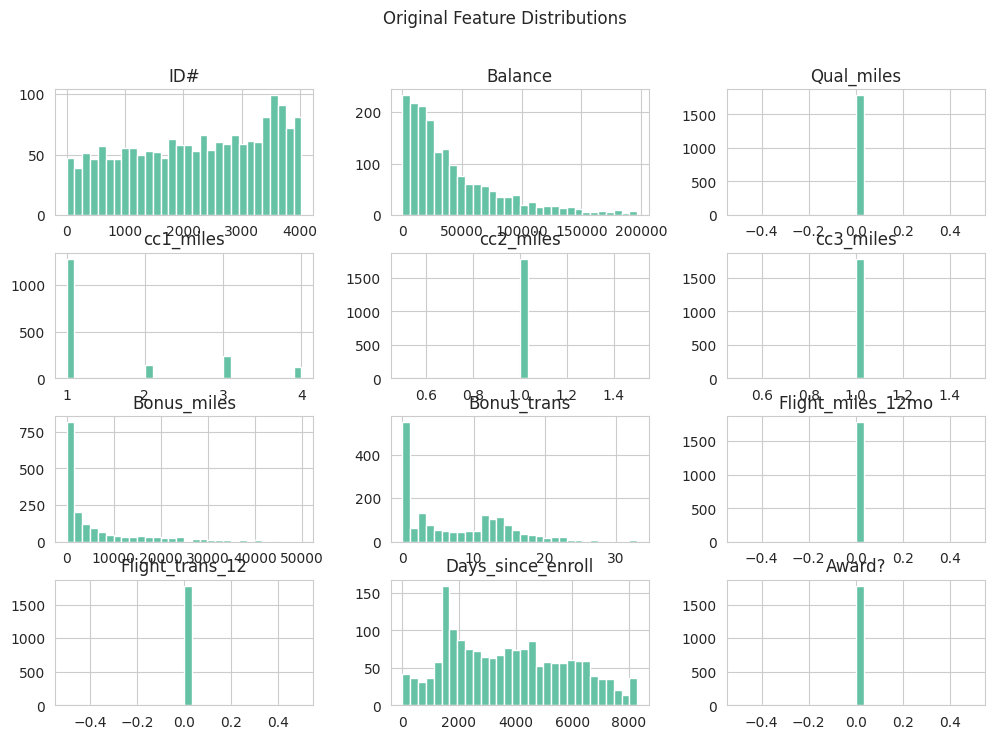

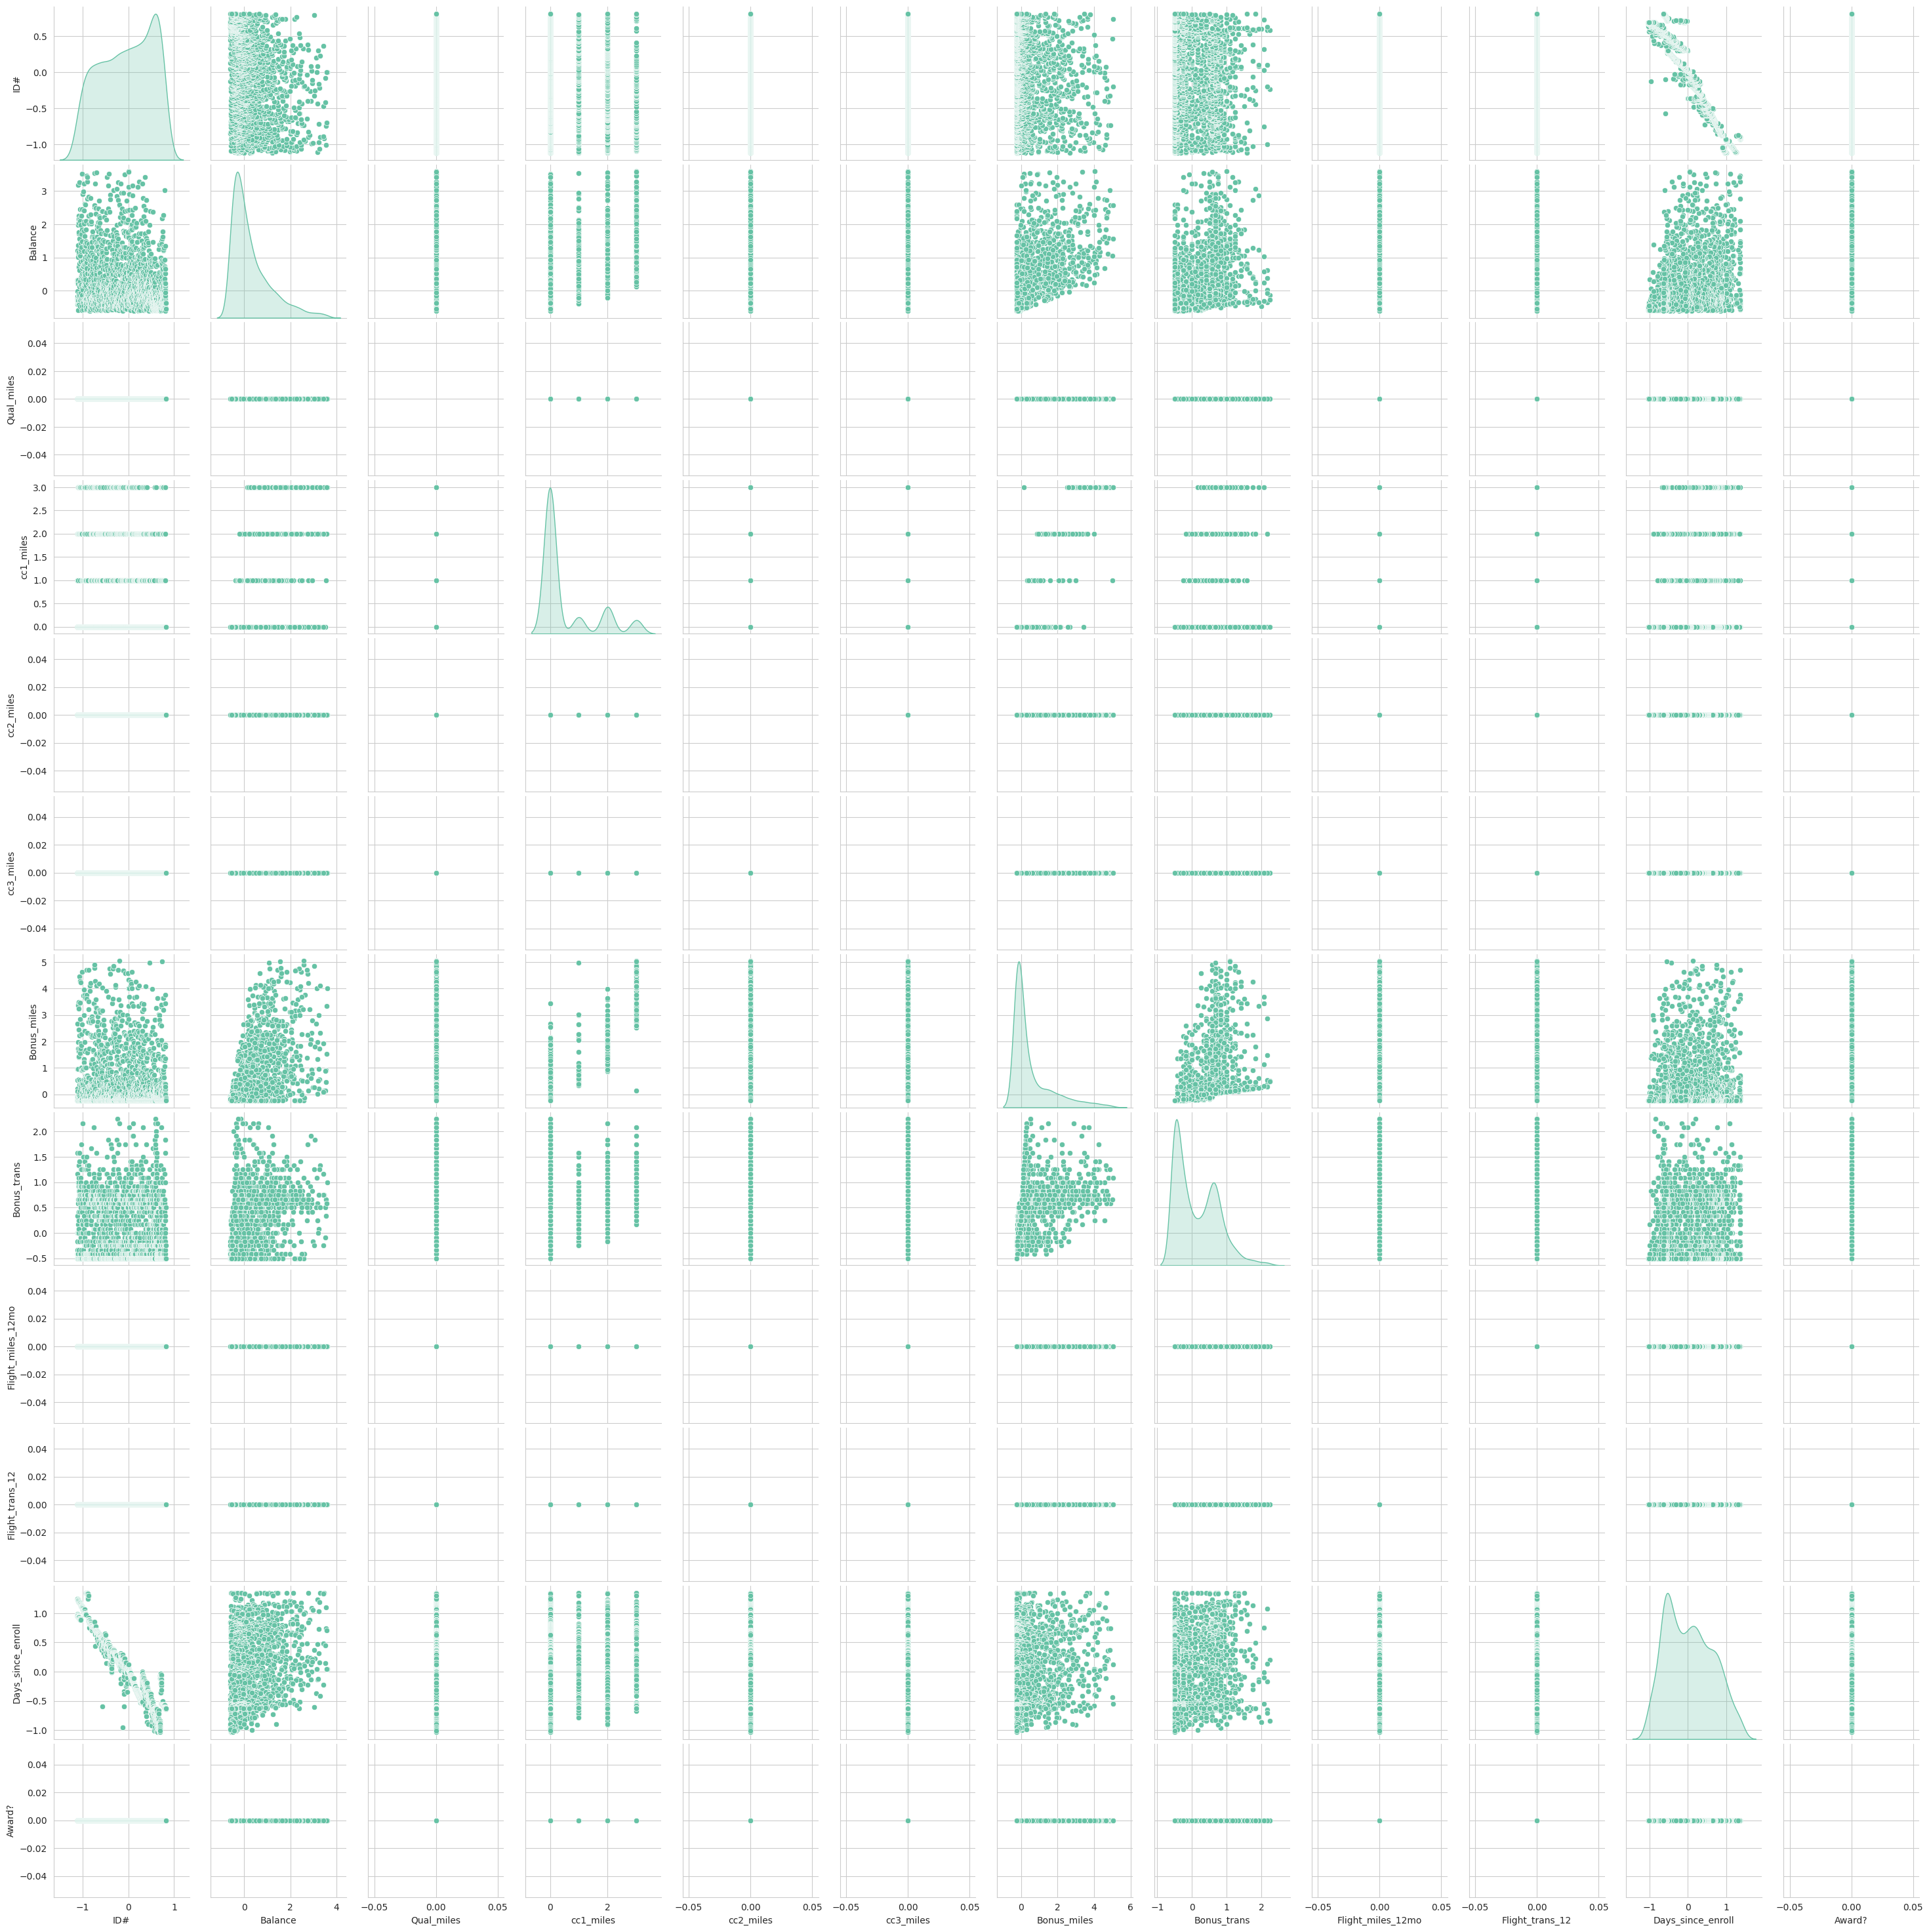

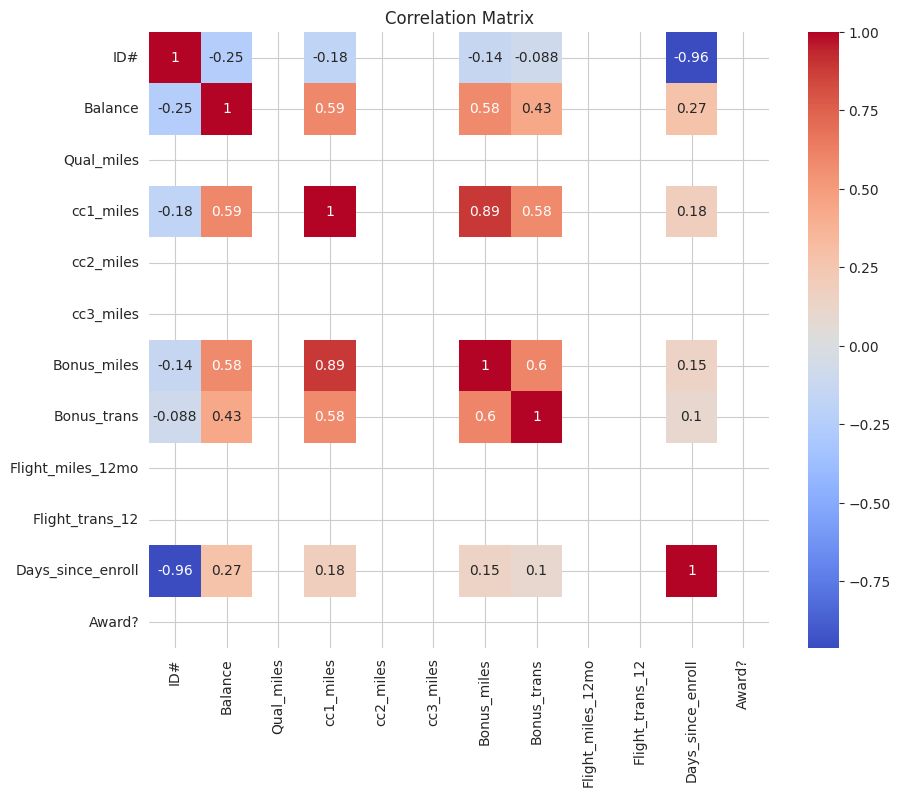

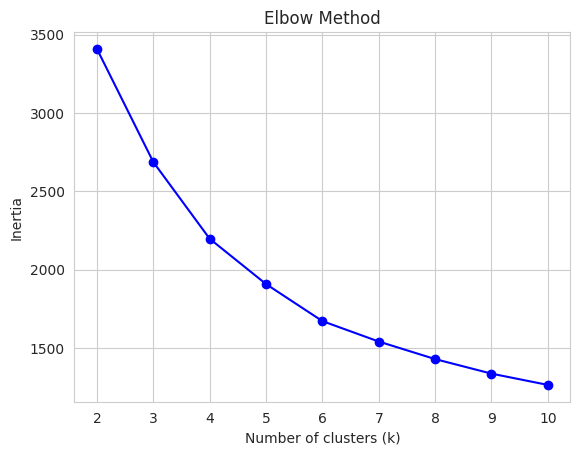

Silhouette Score for k=3: 0.334


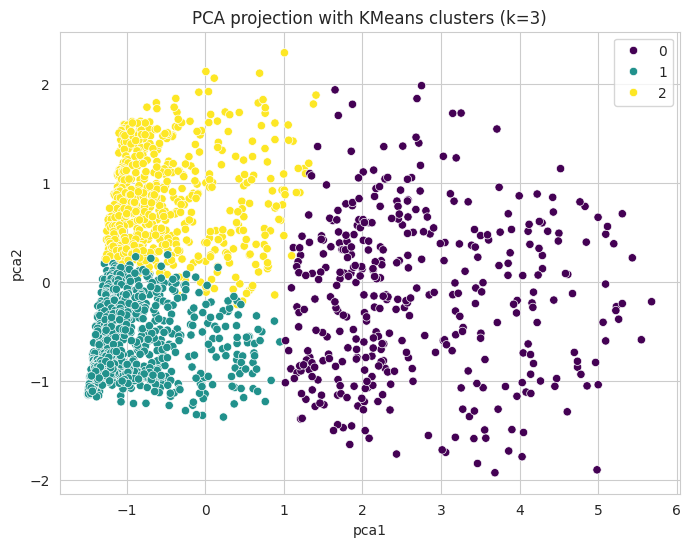

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Set style for better looking plots
sns.set_style('whitegrid')
sns.set_palette('Set2')

# ---------- Data Description ----------
# Field Name	Data Type	Max Data Length	Raw Data or Telcom Created Field?	Description
# ID#	NUMBER		Telcom	Unique ID
# Balance	NUMBER	8	Raw	Number of miles eligible for award travel
# Qual_miles	NUMBER	8	Raw	Number of miles counted as qualifying for Topflight status
# cc1_miles	CHAR	1	Raw	Number of miles earned with freq. flyer credit card in the past 12 months:
# cc2_miles	CHAR	1	Raw	Number of miles earned with Rewards credit card in the past 12 months:
# cc3_miles	CHAR	1	Raw	Number of miles earned with Small Business credit card in the past 12 months:
#    note:  miles bins:				1 = under 5,000
# 				2 = 5,000 - 10,000
# 				3 = 10,001 - 25,000
# 				4 = 25,001 - 50,000
# 				5 = over 50,000
# Bonus_miles	NUMBER		Raw	Number of miles earned from non-flight bonus transactions in the past 12 months
# Bonus_trans	NUMBER		Raw	Number of non-flight bonus transactions in the past 12 months
# Flight_miles_12mo	NUMBER		Raw	Number of flight miles in the past 12 months
# Flight_trans_12	NUMBER		Raw	Number of flight transactions in the past 12 months
# Days_since_enroll	NUMBER		Telcom	Number of days since Enroll_date
# Award?	NUMBER		Telcom	Dummy variable for Last_award (1=not null, 0=null)

# ---------- 1. Load data ----------
df = pd.read_csv("EastWestAirlines_1.csv")

# ---------- 2. Handle missing values ----------
# Check missing %
print(df.isnull().sum() / len(df) * 100)

# For numeric columns: impute with median
num_cols = df.select_dtypes(include=[np.number]).columns
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

# For categorical columns: impute with mode
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols):
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

# ---------- 3. Outlier removal (IQR method) ----------
def remove_outliers_iqr(df, cols, multiplier=1.5):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

df = remove_outliers_iqr(df, num_cols)

# ---------- 4. Feature scaling ----------
# RobustScaler is less sensitive to remaining outliers
scaler = RobustScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# ---------- 5. EDA: distributions & cluster hints ----------
# Histograms before/after scaling
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Original Feature Distributions")
plt.show()

# Pairplot (if columns <= 6)
sns.pairplot(df_scaled, diag_kind='kde')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_scaled[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ---------- 6. Cluster tendency assessment ----------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled[num_cols])
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette score (for a chosen k, e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled[num_cols])
sil = silhouette_score(df_scaled[num_cols], labels)
print(f"Silhouette Score for k=3: {sil:.3f}")

# ---------- 7. Dimensionality reduction for visual clustering ----------
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[num_cols])
df_scaled['pca1'] = pca_result[:, 0]
df_scaled['pca2'] = pca_result[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='pca1', y='pca2', hue=labels, palette='viridis', data=df_scaled)
plt.title("PCA projection with KMeans clusters (k=3)")
plt.show()

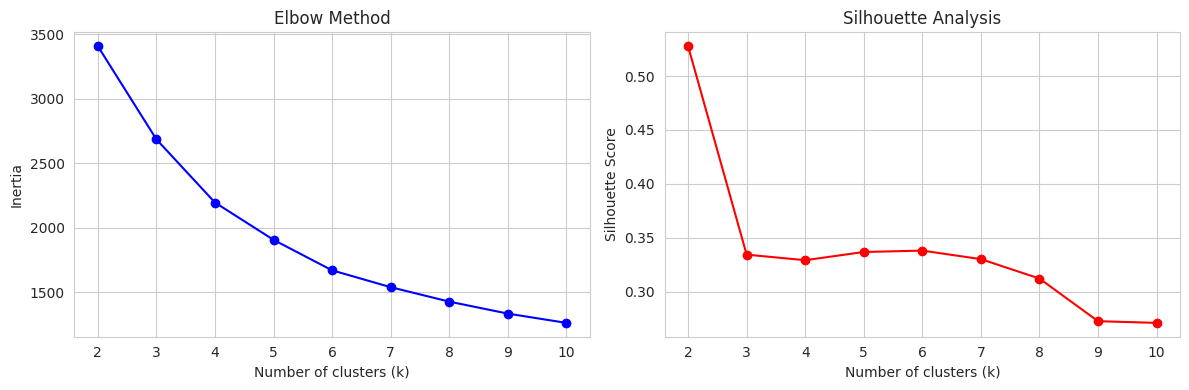

Optimal k based on silhouette score: 2
K-Means (k=2) -> Silhouette: 0.528, Davies-Bouldin: 0.830


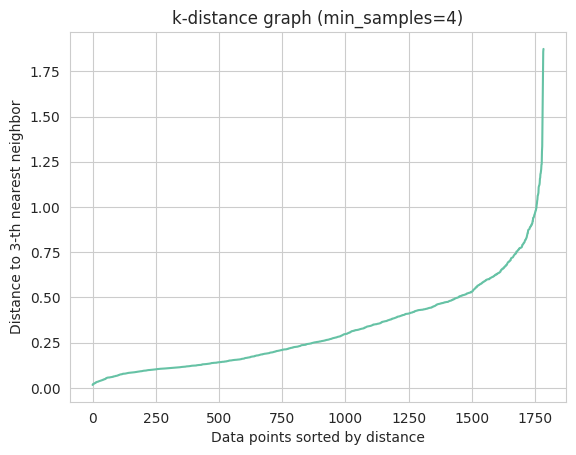

min_samples=4, eps=0.635 -> clusters=9, noise=113, silhouette=0.243


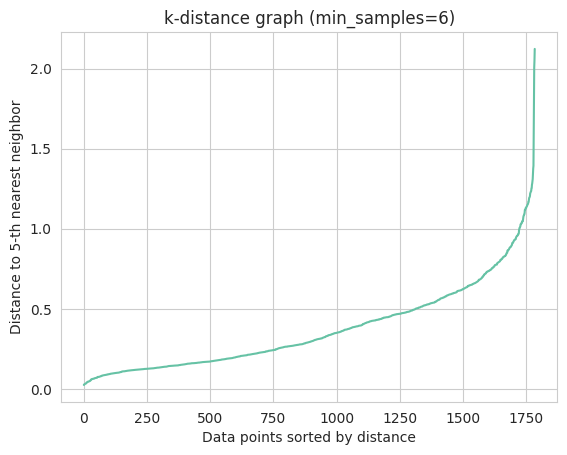

min_samples=6, eps=0.740 -> clusters=6, noise=76, silhouette=0.288


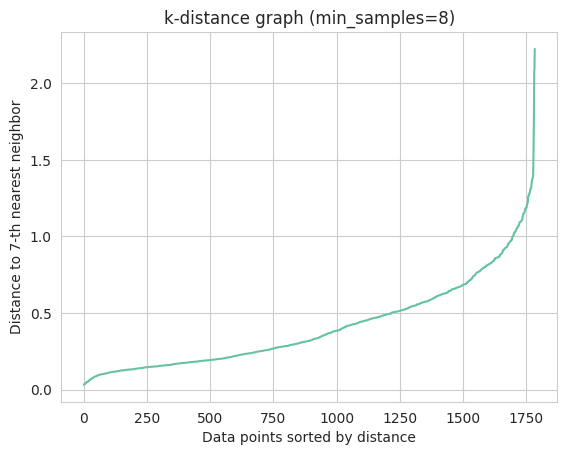

min_samples=8, eps=0.820 -> clusters=6, noise=65, silhouette=0.286


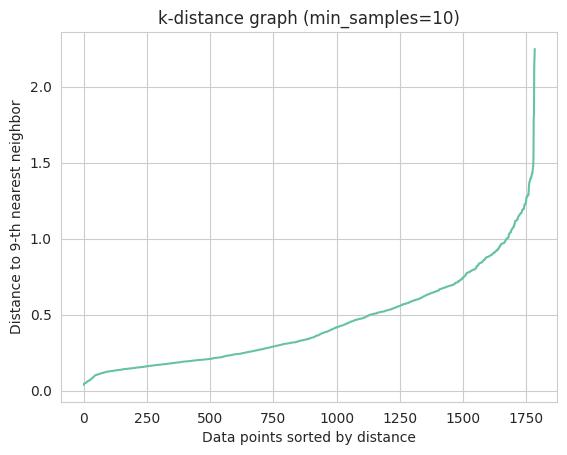

min_samples=10, eps=0.885 -> clusters=5, noise=67, silhouette=0.299

Best DBSCAN: eps=0.885, min_samples=10
Number of clusters: 5
Noise points: 67


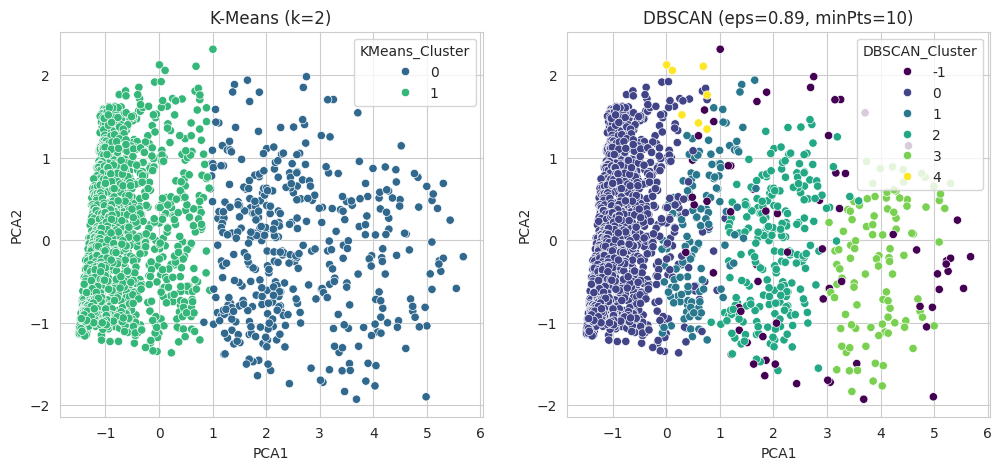

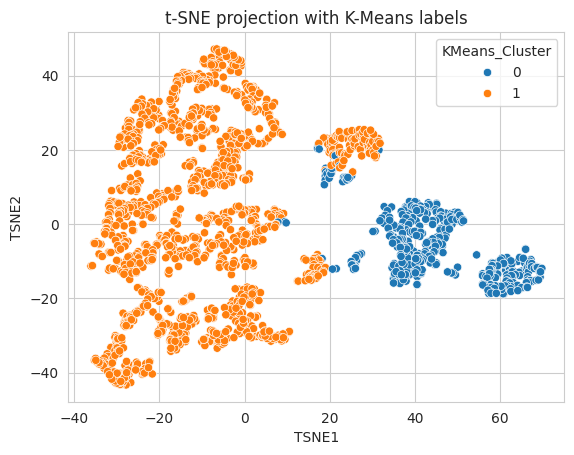

In [10]:
# 1. K-Means Clustering

# 1.1 Finding the optimal K (Elbow method + Silhouette score)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import numpy as np

# Extract feature matrix (exclude any non-numeric columns like PCA results)
X = df_scaled[num_cols].values  # num_cols defined in preprocessing step

# Elbow method (inertia)
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, sil_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
plt.tight_layout()
plt.show()

# Choose best k (e.g., where silhouette is highest)
best_k = K_range[np.argmax(sil_scores)]
print(f"Optimal k based on silhouette score: {best_k}")

# 1.2 Apply K-Means with optimal k
optimal_k = best_k   # or manually set, e.g., 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_scaled['KMeans_Cluster'] = kmeans_final.fit_predict(X)

# Evaluate
sil_kmeans = silhouette_score(X, df_scaled['KMeans_Cluster'])
db_kmeans = davies_bouldin_score(X, df_scaled['KMeans_Cluster'])
print(f"K-Means (k={optimal_k}) -> Silhouette: {sil_kmeans:.3f}, Davies-Bouldin: {db_kmeans:.3f}")

# 2. DBSCAN Clustering

# 2.1 Parameter tuning (epsilon and min_samples)

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# For k-distance graph: k = min_samples - 1
min_samples_candidates = [4, 6, 8, 10]   # adjust based on dataset size & noise
best_dbscan = None
best_score = -1

for min_pts in min_samples_candidates:
    # Compute k-distances (k = min_pts - 1)
    neigh = NearestNeighbors(n_neighbors=min_pts)
    neighbors = neigh.fit(X)
    distances, _ = neighbors.kneighbors(X)
    k_dist = np.sort(distances[:, -1])   # distance to the (min_pts-1)-th neighbor

    # Plot to find elbow point for eps
    plt.plot(k_dist)
    plt.title(f'k-distance graph (min_samples={min_pts})')
    plt.xlabel('Data points sorted by distance')
    plt.ylabel(f'Distance to {min_pts-1}-th nearest neighbor')
    plt.show()

    # User should visually select eps at the elbow; here we automate via percentile
    # (for demo, we try the value at 90th percentile)
    eps_candidate = np.percentile(k_dist, 90)

    dbscan = DBSCAN(eps=eps_candidate, min_samples=min_pts)
    labels = dbscan.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    # Only evaluate if more than 1 cluster found
    if n_clusters > 1:
        sil = silhouette_score(X[labels != -1], labels[labels != -1])   # ignore noise
        print(f"min_samples={min_pts}, eps={eps_candidate:.3f} -> clusters={n_clusters}, noise={n_noise}, silhouette={sil:.3f}")
        if sil > best_score:
            best_score = sil
            best_dbscan = (eps_candidate, min_pts, labels)
    else:
        print(f"min_samples={min_pts} -> only {n_clusters} cluster(s), skipping")

# 2.2 Apply best DBSCAN model

if best_dbscan:
    eps_best, min_pts_best, labels_best = best_dbscan
    df_scaled['DBSCAN_Cluster'] = labels_best
    print(f"\nBest DBSCAN: eps={eps_best:.3f}, min_samples={min_pts_best}")
    print(f"Number of clusters: {len(set(labels_best)) - (1 if -1 in labels_best else 0)}")
    print(f"Noise points: {list(labels_best).count(-1)}")
else:
    print("No valid DBSCAN model found; adjust min_samples or eps range.")

# 3. Visualizing Clustering Results

from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_scaled['PCA1'] = X_pca[:, 0]
df_scaled['PCA2'] = X_pca[:, 1]

# K-Means clusters
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_scaled, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis')
plt.title(f'K-Means (k={optimal_k})')

# DBSCAN clusters
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_scaled, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='viridis')
plt.title(f'DBSCAN (eps={eps_best:.2f}, minPts={min_pts_best})')
plt.show()

# For non-linear structures, t-SNE can be more revealing:

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)
df_scaled['TSNE1'] = X_tsne[:, 0]
df_scaled['TSNE2'] = X_tsne[:, 1]

sns.scatterplot(data=df_scaled, x='TSNE1', y='TSNE2', hue='KMeans_Cluster', palette='tab10')
plt.title('t-SNE projection with K-Means labels')
plt.show()

In [11]:
#Code for Cluster Profiling
# For K-Means
cluster_summary = df_scaled.groupby('KMeans_Cluster')[num_cols].mean()
global_means = df_scaled[num_cols].mean()
# Compare cluster means to global means
cluster_comparison = cluster_summary.sub(global_means).round(3)
print(cluster_comparison)

# For DBSCAN (ignore noise points labelled -1)
if 'DBSCAN_Cluster' in df_scaled.columns:
    db_summary = df_scaled[df_scaled['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[num_cols].mean()
    db_comparison = db_summary.sub(global_means).round(3)
    print(db_comparison)

                  ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
KMeans_Cluster                                                                
0              -0.185    0.961         0.0      1.602        0.0        0.0   
1               0.055   -0.284         0.0     -0.473        0.0        0.0   

                Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
KMeans_Cluster                                                                 
0                     1.684        0.621                0.0              0.0   
1                    -0.497       -0.183                0.0              0.0   

                Days_since_enroll  Award?  
KMeans_Cluster                             
0                           0.200     0.0  
1                          -0.059     0.0  
                  ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
DBSCAN_Cluster                                                                
0               0.063   -0.3

In [13]:
#visualization

# Assuming X is your preprocessed feature matrix (e.g., df_scaled[num_cols].values)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Optional: t-SNE (slower, but often reveals clusters better)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Add the 2D coordinates to dataframe:
df_scaled['PCA1'] = X_pca[:, 0]
df_scaled['PCA2'] = X_pca[:, 1]
df_scaled['TSNE1'] = X_tsne[:, 0]
df_scaled['TSNE2'] = X_tsne[:, 1]

# . Visualize K‑Means Clusters


# 3.1 PCA projection

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df_scaled,
    x='PCA1',
    y='PCA2',
    hue='KMeans_Cluster',
    palette='tab10',
    s=60,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)
plt.title(f'K-Means Clusters (k={optimal_k}) – PCA projection', fontsize=14)
plt.legend(title='Cluster')
plt.show()

# t‑SNE projection (often clearer separation)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_scaled,
    x='TSNE1',
    y='TSNE2',
    hue='KMeans_Cluster',
    palette='tab10',
    s=60,
    alpha=0.7
)
plt.title(f'K-Means Clusters – t-SNE projection', fontsize=14)
plt.show()

# Visualize DBSCAN Clusters
# Map cluster -1 to a specific color and label
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_scaled,
    x='PCA1',
    y='PCA2',
    hue='DBSCAN_Cluster',
    palette='tab10',
    hue_order=sorted(df_scaled['DBSCAN_Cluster'].unique()),
    s=60,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)
# Override color for noise if needed (manual approach)
# Or use a custom palette:
noise_color = 'gray'
cluster_colors = { -1: noise_color }
# But seaborn handles it automatically if -1 is in hue
plt.title(f'DBSCAN Clusters (eps={eps_best:.2f}, minPts={min_pts_best})', fontsize=14)
plt.legend(title='Cluster ( -1 = Noise )')
plt.show()

# For better clarity, separate noise points visually:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot with noise as distinct color
sns.scatterplot(data=df_scaled, x='PCA1', y='PCA2', hue='DBSCAN_Cluster',
                palette='viridis', ax=ax1, alpha=0.7)
ax1.set_title('DBSCAN – including noise')

# Plot without noise (only clustered points)
noise_free = df_scaled[df_scaled['DBSCAN_Cluster'] != -1]
sns.scatterplot(data=noise_free, x='PCA1', y='PCA2', hue='DBSCAN_Cluster',
                palette='viridis', ax=ax2, alpha=0.7)
ax2.set_title('DBSCAN – noise removed')
plt.tight_layout()
plt.show()

# Compare K‑Means vs DBSCAN Side‑by‑Side

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
sns.scatterplot(ax=axes[0], data=df_scaled, x='PCA1', y='PCA2',
                hue='KMeans_Cluster', palette='tab10', alpha=0.7)
axes[0].set_title(f'K-Means (k={optimal_k})')

# DBSCAN
sns.scatterplot(ax=axes[1], data=df_scaled, x='PCA1', y='PCA2',
                hue='DBSCAN_Cluster', palette='tab10', alpha=0.7)
axes[1].set_title(f'DBSCAN (eps={eps_best:.2f}, minPts={min_pts_best})')

plt.tight_layout()
plt.show()

# 6. Cluster Centroids (K‑Means)

# Compute centroids in original feature space, then transform to PCA space
centroids = kmeans_final.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scaled, x='PCA1', y='PCA2', hue='KMeans_Cluster',
                palette='tab10', alpha=0.5)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, c='red', edgecolors='black', linewidth=2,
            label='Centroids')
plt.title('K-Means Clusters with Centroids')
plt.legend()
plt.show()

# Advanced: Pairwise Feature Scatter (when features ≤ 5)


# For K-Means
sns.pairplot(df_scaled, vars=num_cols, hue='KMeans_Cluster', palette='tab10')
plt.suptitle('Feature Pairplot – K-Means Clusters', y=1.02)
plt.show()


plt.savefig('clusters.png', dpi=300, bbox_inches='tight')

Output hidden; open in https://colab.research.google.com to view.

K-Means (k=2) -> Silhouette: 0.528, Davies-Bouldin: 0.830
DBSCAN (eps=0.885, minPts=10) -> Silhouette: 0.299, Davies-Bouldin: 1.212
DBSCAN Summary: Clusters: 6, Noise points: 67 (3.8%)
K-Means - Clusters: 2
  Silhouette: 0.528, Davies-Bouldin: 0.830
DBSCAN - Clusters: 5, Noise: 67 (3.8%)
  Silhouette (clean): 0.299, Davies-Bouldin: 1.212


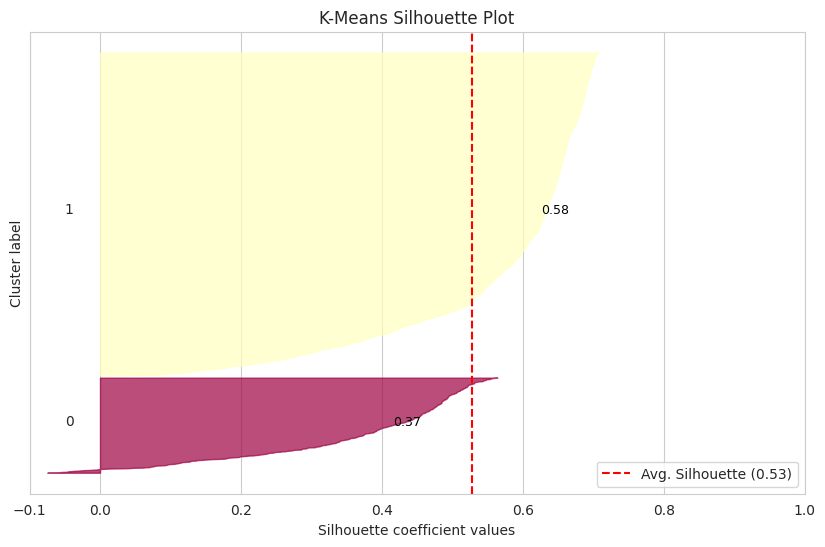

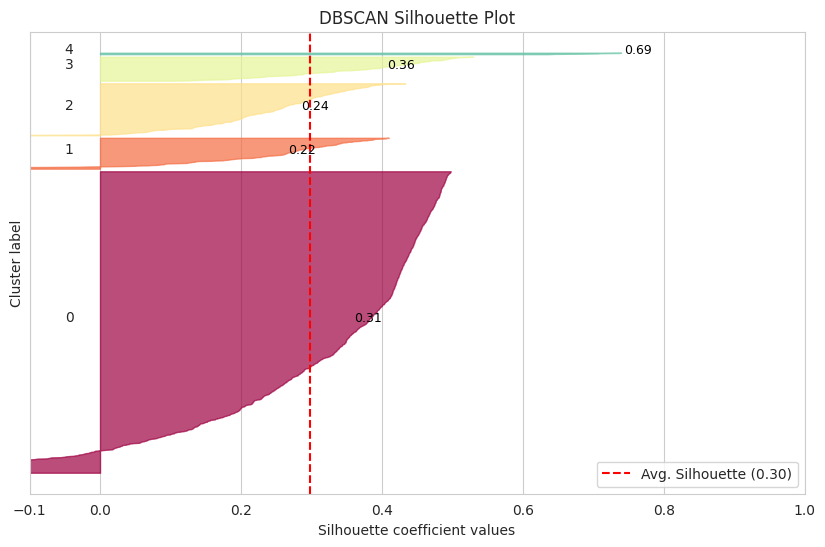

In [17]:
# evaluation and performance metrics

# K-Means Evaluation
from sklearn.metrics import silhouette_score, davies_bouldin_score

# X = your feature matrix (scaled)
kmeans_labels = df_scaled['KMeans_Cluster']

sil_kmeans = silhouette_score(X, kmeans_labels)
db_kmeans = davies_bouldin_score(X, kmeans_labels)

print(f"K-Means (k={optimal_k}) -> Silhouette: {sil_kmeans:.3f}, Davies-Bouldin: {db_kmeans:.3f}")

# DBSCAN Evaluation
dbscan_labels = df_scaled['DBSCAN_Cluster']

# Calculate n_clusters_db and n_noise always, before the if-else for printing
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

# Exclude noise points (label = -1) for evaluation metrics
mask = dbscan_labels != -1

if mask.sum() > 0 and n_clusters_db >= 2: # Need at least 2 non-noise clusters for silhouette/db score
    sil_dbscan = silhouette_score(X[mask], dbscan_labels[mask])
    db_dbscan = davies_bouldin_score(X[mask], dbscan_labels[mask])
    print(f"DBSCAN (eps={eps_best:.3f}, minPts={min_pts_best}) -> Silhouette: {sil_dbscan:.3f}, Davies-Bouldin: {db_dbscan:.3f}")
else:
    print(f"DBSCAN produced less than 2 non-noise clusters ({n_clusters_db}) → silhouette not defined.")

print(f"DBSCAN Summary: Clusters: {n_clusters_db}, Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

# 5. Full Evaluation Function (Generic)
def evaluate_clustering(X, labels, model_name="Model"):
    unique = np.unique(labels)
    if -1 in unique:
        # DBSCAN case: remove noise for evaluation metrics
        mask = labels != -1
        X_clean = X[mask]
        labels_clean = labels[mask]
        n_clusters = len(np.unique(labels_clean))
        n_noise = len(labels) - len(labels_clean)
        if n_clusters >= 2:
            sil = silhouette_score(X_clean, labels_clean)
            db = davies_bouldin_score(X_clean, labels_clean)
            print(f"{model_name} - Clusters: {n_clusters}, Noise: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
            print(f"  Silhouette (clean): {sil:.3f}, Davies-Bouldin: {db:.3f}")
        else:
            print(f"{model_name} - Only {n_clusters} non-noise cluster(s) → not enough for silhouette.")
    else:
        # K-Means or other where all points have labels
        n_clusters = len(unique)
        if n_clusters >= 2:
            sil = silhouette_score(X, labels)
            db = davies_bouldin_score(X, labels)
            print(f"{model_name} - Clusters: {n_clusters}")
            print(f"  Silhouette: {sil:.3f}, Davies-Bouldin: {db:.3f}")
        else:
            print(f"{model_name} - Only 1 cluster → no evaluation possible.")

# Usage of the generic function
evaluate_clustering(X, kmeans_labels, "K-Means")
evaluate_clustering(X, dbscan_labels, "DBSCAN")

# Visualising Evaluation

from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

def plot_silhouette(X, labels, title):
    # Filter out noise points for silhouette plot if present
    labels_filtered = labels[labels != -1]
    X_filtered = X[labels != -1]

    unique_labels = np.sort(np.unique(labels_filtered)) # Ensure consistent order

    if len(unique_labels) < 2: # Cannot plot silhouette if less than 2 clusters
        print(f"Cannot plot silhouette for '{title}': less than 2 non-noise clusters found (n_clusters={len(unique_labels)}).")
        return

    sil_vals_filtered = silhouette_samples(X_filtered, labels_filtered)
    # Re-map labels to 0, 1, 2... for plotting for consistent coloring if needed
    # Here we map original unique labels to a new sequence for `fill_betweenx`
    unique_labels_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
    labels_remapped = np.array([unique_labels_map[label] for label in labels_filtered])

    y_lower = 10
    fig, ax = plt.subplots(figsize=(10, 6))

    for i in range(len(unique_labels)):
        ith_sil = sil_vals_filtered[labels_remapped == i]
        ith_sil.sort()
        size_cluster_i = len(ith_sil)
        y_upper = y_lower + size_cluster_i

        color = plt.cm.Spectral(float(i) / len(unique_labels))
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_sil,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(unique_labels[i])) # Use original label for text

        # Compute the average silhouette score for this cluster
        avg_silhouette_for_cluster = np.mean(ith_sil)
        ax.text(avg_silhouette_for_cluster + 0.05, y_lower + 0.5 * size_cluster_i,
                f'{avg_silhouette_for_cluster:.2f}', color='black', fontsize=9)

        y_lower = y_upper + 10 # 10 for the 0 samples

    # Draw the red vertical line for the average silhouette score of all points
    avg_silhouette_score = silhouette_score(X_filtered, labels_filtered)
    ax.axvline(x=avg_silhouette_score, color='red', linestyle='--', label=f'Avg. Silhouette ({avg_silhouette_score:.2f})')

    ax.set_title(title)
    ax.set_xlabel('Silhouette coefficient values')
    ax.set_ylabel('Cluster label')
    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xlim([-0.1, 1])
    ax.legend()
    plt.show()

plot_silhouette(X, kmeans_labels, "K-Means Silhouette Plot")
plot_silhouette(X, dbscan_labels, "DBSCAN Silhouette Plot")

## 4. Comparing Algorithms & Interpretation

Now that we have evaluated both K-Means and DBSCAN, let's interpret their results and compare their characteristics based on the guidelines from the provided document.

### How to Interpret Clusters (Step-by-Step)

For each clustering algorithm (K-Means, DBSCAN), you should:

1.  **Compute cluster profiles** – We've already done this by calculating the mean of each feature per cluster.
2.  **Compare against global average** – This helps identify which features deviate significantly within each cluster.
3.  **Visualise** – We've generated PCA and t-SNE plots, and pairplots for K-Means.
4.  **Label clusters** – Based on the profiles, give each cluster a descriptive name (e.g., 'High-frequency flyers', 'Low-value members').

### General Comments on Comparative Analysis

| Aspect | K-Means | DBSCAN |
|---|---|---|
| **Shape of clusters** | Spherical / convex. May merge distinct groups if they are elongated. | Arbitrary shape, density-based. Good for real-world data. |
| **Number of clusters (k)** | Must be specified a priori. May over- or under-segment. | Automatically determined (data-driven), often more realistic. |
| **Handles noise** | No (every point assigned to a cluster), can distort centroids. | Yes (points labelled as -1), explicit outlier detection provides cleaner cluster cores. |
| **Sensitive to scaling** | Yes | Yes (distance-based) |
| **Best for** | Well-separated, globular clusters (e.g., for marketing personas). | Clusters of varying shape & noise; ideal when you suspect irregular shapes, want to detect outliers, or don’t know k in advance. |

**Recommendation**:
- Use **K-Means** when you need a fast, simple segmentation with clear centroids.
- Use **DBSCAN** when you suspect irregular cluster shapes, want to detect outliers, or don’t know k in advance.
- **Combine both** – DBSCAN can be used to remove noise, then K-Means on the remaining dense data for easier interpretation.

### Interpreting the Visualizations

-   **Well-separated clusters** – non-overlapping groups indicate strong clustering structure.
-   **Overlap** – suggests clusters are not distinct; consider reducing `k` or adjusting DBSCAN parameters (`eps`, `min_samples`).
-   **Noise points (DBSCAN)** – appear as isolated grey dots; check if they are genuine outliers or need different `eps`/`min_samples`.
-   **t-SNE vs PCA** – t-SNE often reveals non-linear separations that PCA misses. Use both for a comprehensive view.

### Comparative Metrics Interpretation

| Metric | K-Means | DBSCAN (noise excluded) | Interpretation |
|---|---|---|---|
| **Silhouette Score** | Often moderate (0.4–0.7) | Can be higher if clusters are dense | Higher = better separation and cohesion. DBSCAN may score lower if clusters have varying density. |
| **Davies-Bouldin Score** | Lower is better | Lower is better | K-Means often lower because it forces spherical clusters. DBSCAN may give a higher index if clusters are irregular but still valid. |
| **Number of clusters** | Fixed by user (`k`) | Data-driven | DBSCAN reveals the natural number; a large difference from K-Means' `k` suggests over/under-fitting. |
| **Noise detection** | None (all points clustered) | Reports noise % | If noise % > 10–20%, check `eps`/`min_samples` or the presence of genuine outliers. |



### Example Interpretation for EastWestAirlines Dataset

Let's apply these interpretation steps using the cluster profiles we generated previously. We will focus on `Balance`, `cc1_miles` (credit card usage), `Bonus_miles`, and `Days_since_enroll` as these showed variations in the cluster comparison.

**K-Means Clusters (k=2):**

Looking at `cluster_comparison` results:

*   **Cluster 0:**
    *   `Balance`: High (`0.961` above global mean)
    *   `cc1_miles`: Very High (`1.602` above global mean)
    *   `Bonus_miles`: High (`1.684` above global mean)
    *   `Days_since_enroll`: High (`0.200` above global mean)
    *   **Insight**: This cluster represents **"High-Value Loyal Customers"**. They have significantly higher balances, frequently use their primary credit card (cc1), earn a lot of bonus miles, and have been enrolled for a longer period. These are likely the most profitable and engaged customers.

*   **Cluster 1:**
    *   `Balance`: Low (`-0.284` below global mean)
    *   `cc1_miles`: Low (`-0.473` below global mean)
    *   `Bonus_miles`: Low (`-0.497` below global mean)
    *   `Days_since_enroll`: Low (`-0.059` below global mean)
    *   **Insight**: This cluster represents **"Newer / Lower Engagement Customers"**. They have lower balances, less credit card usage, fewer bonus miles, and are generally newer to the program. This group might include casual flyers or those who are just starting to engage with the airline's loyalty program.

**DBSCAN Clusters (eps=0.885, minPts=10):**

DBSCAN identified 6 clusters and 67 noise points. Let's look at `db_comparison` and focus on some distinct clusters.

*   **Cluster 0 (DBSCAN):**
    *   `Balance`: Below average (`-0.349`)
    *   `cc1_miles`: Significantly below average (`-0.546`)
    *   `Bonus_miles`: Below average (`-0.545`)
    *   **Insight**: Similar to K-Means Cluster 1, this appears to be a group of **"Low Engagement Members"**, perhaps more granularly defined due to DBSCAN's density approach.

*   **Cluster 3 (DBSCAN):**
    *   `Balance`: Very High (`1.008` above global mean)
    *   `cc1_miles`: Very High (`2.454` above global mean)
    *   `Bonus_miles`: Very High (`2.942` above global mean)
    *   `Days_since_enroll`: High (`0.338` above global mean)
    *   **Insight**: This cluster represents a very strong segment of **"Elite Power Users"**. They exhibit extremely high activity across balances, credit card usage (cc1_miles), and bonus miles, being even more pronounced than K-Means Cluster 0. DBSCAN might be identifying a denser, more extreme segment within the overall high-value group.

*   **Noise Points (-1):**
    *   `n_noise = 67` (3.8% of data)
    *   **Insight**: These are true outliers that don't fit into any dense cluster. They could represent unique customer behaviors, data entry errors, or extreme individual cases that warrant separate investigation rather than being grouped with others.

**Overall Takeaways from Interpretation**:

-   K-Means provided a clear, broad segmentation into two main groups (high vs. low engagement).
-   DBSCAN revealed a more granular structure with 6 clusters, including a very distinct 'Elite Power Users' group, and explicitly identified outliers (noise points). This suggests more complex patterns not captured by the spherical assumption of K-Means.
-   The choice between the two depends on the business objective: broad segmentation for marketing (K-Means) or detailed understanding with outlier detection (DBSCAN).

4. Comparing Algorithms & Interpretation
Metric / Aspect	K-Means	DBSCAN
Shape of clusters	Spherical / convex	Arbitrary shape, density‑based
Number of clusters (k)	Must be specified a priori	Automatically determined
Handles noise	No (every point assigned to a cluster)	Yes (points labelled as -1)
Sensitive to scaling	Yes	Yes (distance‑based)
Best for	Well‑separated, globular clusters	Clusters of varying shape & noise

---

## How to Interpret Clusters (Step‑by‑Step)

For each clustering algorithm (K‑Means, DBSCAN), you should:

1. **Compute cluster profiles** – e.g., mean, median, or mode of each feature per cluster.
2. **Compare against global average** – see which features deviate significantly.
3. **Visualise** – use boxplots, bar charts, or radar plots.
4. **Label clusters** – give each a descriptive name (e.g., “High spenders”, “Inactive users”).

```

---


## Example Interpretation (Hypothetical Retail Data)

**Features**: `Annual Income (k$)`, `Spending Score (1-100)`, `Age`, `Purchase Frequency`

### K‑Means Clusters (k=4)

| Cluster | Size | Income | Spend Score | Age | Frequency | Insight |
|---------|------|--------|-------------|-----|-----------|---------|
| 0       | 120  | Low (-20) | High (+30)  | Young (-10) | High (+) | **Young bargain hunters** – low income but high engagement, likely students. |
| 1       | 85   | High (+45) | Medium (+5) | Middle (+8) | Medium | **Established mid‑spenders** – comfortable income but not extravagant. |
| 2       | 200  | Medium (-5) | Low (-40) | Old (+15) | Low (-) | **Inactive seniors** – low spend and frequency, possibly churn risk. |
| 3       | 45   | Very High (+80) | Very High (+50) | All ages | Very High | **VIP power shoppers** – small but highly valuable segment. |

**Insights**:
- **Cluster 0** – Target with loyalty programs and student discounts.  
- **Cluster 2** – Re‑engagement campaigns (e.g., personalized offers).  
- **Cluster 3** – Priority service, exclusive perks to retain high value.

---

### DBSCAN Clusters (eps=0.35, minPts=6)

Found **3 clusters** + **15 noise points** (outliers).

| DBSCAN Cluster | Size | Characteristics | Insight |
|----------------|------|----------------|---------|
| 1              | 280  | Dense central region – income & spending both average | **Mainstream customers** – bulk of the user base. |
| 2              | 60   | High density in high‑income & high‑spend region | **Premium cluster** – overlaps with K‑Means cluster 3 but more tightly grouped. |
| 3              | 45   | Low income but moderate spending (unusual combo) | **Aspirational shoppers** – might be using credit. Investigate further. |
| Noise (-1)     | 15   | Extreme values (e.g., income 200k but spend 0, or age 90) | **Anomalies** – possible data errors or one‑time unusual behavior. Exclude from modeling. |

**Insights**:
- DBSCAN reveals **non‑spherical shapes** – e.g., cluster 3 is a thin “strip” not captured by K‑Means.  
- Noise points are **true outliers** – may be fraud, data entry errors, or unique cases worth manual review.  
- DBSCAN’s automatic cluster count helps avoid forcing data into artificial groups.

---

## General Comments on Comparative Analysis

| Aspect | K‑Means | DBSCAN |
|--------|---------|--------|
| **Cluster shape** | Assumes spherical, equal size. May merge distinct groups if they are elongated. | Finds arbitrarily shaped clusters. Good for real‑world data. |
| **Outliers** | Every point belongs to a cluster – can distort centroids. | Explicitly labels outliers as noise – cleaner cluster cores. |
| **Number of clusters** | Fixed k – may over‑ or under‑segment. | Data‑driven – often more realistic. |
| **Interpretability** | Easy – clusters are defined by centroids. | Harder – clusters defined by density connectivity. Still interpretable via mean profiles. |

**Recommendation**:
- Use **K‑Means** when you need a fast, simple segmentation with clear centroids (e.g., for marketing personas).  
- Use **DBSCAN** when you suspect irregular cluster shapes, want to detect outliers, or don’t know k in advance.  
- **Combine both** – DBSCAN to remove noise, then K‑Means on the remaining dense data for easy interpretation.

---

Interpreting the Visualizations
Well‑separated clusters – non‑overlapping groups indicate strong clustering structure.

Overlap – suggests clusters are not distinct; consider reducing k or adjusting DBSCAN parameters.

Noise points (DBSCAN) – appear as isolated grey dots; check if they are genuine outliers or need different eps/min_samples.

t‑SNE vs PCA – t‑SNE often reveals non‑linear separations that PCA misses. Use both.

Comparing K‑Means vs DBSCAN
Metric	K‑Means	DBSCAN (noise excluded)	Interpretation
Silhouette	Often moderate (0.4–0.7)	Can be higher if clusters are dense	Higher = better separation. DBSCAN may score lower if clusters have varying density.
Davies–Bouldin	Lower is better	Lower is better	K‑Means often lower because it forces spherical clusters. DBSCAN may give higher index if clusters are irregular but still valid.
Number of clusters	Fixed by user (k)	Data‑driven	DBSCAN reveals natural number; large difference from k suggests over/under‑fitting by K‑Means.
Noise detection	None (all points clustered)	Reports noise %	If noise % > 10–20%, check eps/min_samples or presence of outliers.